# C2 Feature Importance Analysis

In [74]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.inspection import permutation_importance

RESULTS_DIR = '/zhome/d0/a/221493/thesis/results'
DISEASE = 'effusion'
N_FOLDS = 5

# Folder to save cached importances
CACHE_DIR = os.path.join(RESULTS_DIR, 'C2_importances_cache')
os.makedirs(CACHE_DIR, exist_ok=True)


## Load the predictions (saved from C2)


In [75]:
# Load all fold predictions
all_preds = []
for fold in range(N_FOLDS):
    fold_path = f'{RESULTS_DIR}/C2_sim_cf/{DISEASE}/cv_results/cf_1/fold_{fold}_predictions.csv'
    all_preds.append(pd.read_csv(fold_path))

# Identify feature columns (exclude model _prob outputs)
selected_cols = [col for col in all_preds[0].columns if not any(m in col for m in ['MLP', 'LR', 'RF'])]
print("Selected feature columns:", selected_cols[:10])


Selected feature columns: ['path', 'effusion_prob', 'effusion_true', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6']


In [76]:
def build_M6_features(df, disease):
    """Extract M6 feature matrix from a fold DataFrame."""
    meta_cols = {f'{disease}_prob', f'{disease}_pred', f'{disease}_true',
                 'correct', 'path', 'patient_id', 'cf_prob', 'cf_paths'}
    diff_cols = [c for c in df.columns if c.startswith('delta_')]
    emb_cols  = [c for c in df.columns if c.startswith('emb_')]
    attr_cols = [c for c in df.columns if c not in meta_cols and not c.startswith('delta_') and not c.startswith('emb_')]

    X = np.hstack([
        df[[f'{disease}_prob']].values,
        df[diff_cols].values,
        df[attr_cols].values,
        df[['cf_prob']].values
    ])
    feature_names = [f'{disease}_prob'] + diff_cols + attr_cols + ['cf_prob']
    return X, feature_names

def compute_fold_importance(fold_idx, pred_df, selected_cols):
    """Compute or load cached permutation importance for a fold."""
    cache_path = os.path.join(CACHE_DIR, f'fold_{fold_idx}_importance.pkl')
    if os.path.exists(cache_path):
        print(f'Loading cached fold {fold_idx}')
        return pd.read_pickle(cache_path)
    
    print(f'Computing permutation importance fold {fold_idx}')
    X, feature_names = build_M6_features(pred_df[selected_cols], DISEASE)
    model_path = f'{RESULTS_DIR}/C2_sim_cf/{DISEASE}/cv_results/cf_1/models/MLP/MLP_M6_fold{fold_idx}.pkl'
    saved = joblib.load(model_path)
    model, scaler = saved['model'], saved['scaler']
    X_scaled = scaler.transform(X.astype(np.float32))
    y = pred_df['correct'].values
    
    r = permutation_importance(model, X_scaled, y, n_repeats=20, random_state=42, n_jobs=-1)
    
    fold_df = pd.DataFrame({
        'feature': feature_names,
        'importance': r.importances_mean,
        'std': r.importances_std,
        'fold': fold_idx
    })
    fold_df.to_pickle(cache_path)
    return fold_df



In [77]:
all_importances = [compute_fold_importance(f, pred, selected_cols) for f, pred in enumerate(all_preds)]


Computing permutation importance fold 0
Computing permutation importance fold 1
Computing permutation importance fold 2
Computing permutation importance fold 3
Computing permutation importance fold 4


In [83]:
# Save all importances as pickle
all_importances_path = os.path.join(CACHE_DIR, 'all_importances.pkl')
pd.concat(all_importances, ignore_index=True).to_pickle(all_importances_path)  


In [95]:
all_importances

[                 feature  importance       std  fold        group
 0          effusion_prob    0.070413  0.001414     0        Other
 1           delta_margin    0.002554  0.000596     0  Delta Other
 2         delta_age_pred    0.000184  0.000282     0  Delta Other
 3         delta_sex_male    0.000233  0.000335     0  Delta Other
 4       delta_sex_female    0.000261  0.000255     0  Delta Other
 ..                   ...         ...       ...   ...          ...
 921     lung_width_ratio    0.000000  0.000000     0        Other
 922   left_lung_fraction   -0.000455  0.000240     0        Other
 923  right_lung_fraction    0.000036  0.000299     0        Other
 924    mediastinal_ratio    0.000054  0.000244     0        Other
 925              cf_prob    0.060028  0.001844     0      cf_prob
 
 [926 rows x 5 columns],
                  feature  importance       std  fold        group
 0          effusion_prob    0.076467  0.001970     1        Other
 1           delta_margin    0.0008

In [113]:
# Category-based grouping
RELEVANT_STRUCTURES = ['Left Lung', 'Right Lung', 'Heart', 'Mediastinum', 
                        'Facies Diaphragmatica', 'Aorta', 
                        'Left Hilus Pulmonis', 'Right Hilus Pulmonis']
IRRELEVANT_STRUCTURES = ['Left Scapula', 'Right Scapula', 
                         'Left Clavicle', 'Right Clavicle', 'Weasand', 'Spine']
RELEVANT_RATIOS = ['cardiothoracic_ratio', 'lung_area_ratio', 'lung_height_ratio',
                   'lung_width_ratio', 'left_lung_fraction', 'right_lung_fraction']
DEMO_COLS = ['age_pred', 'sex_male', 'sex_female', 'race_white', 'race_black', 'race_asian']

DELTA_DEMO = [f'delta_{c}' for c in DEMO_COLS]
DELTA_RATIOS = [f'delta_{c}' for c in RELEVANT_RATIOS]

def categorize_feature_v3(feature):
    if feature == f'{DISEASE}_prob':
        return 'C0 Confidence'
    if feature == 'cf_prob':
        return 'CF Probability'
    if feature in DEMO_COLS or feature in DELTA_DEMO:
        return 'Demographics (CF delta)' if feature.startswith('delta_') else 'Demographics'
    if feature in RELEVANT_RATIOS or feature in DELTA_RATIOS:
        return 'Relevant Ratios (CF delta)' if feature.startswith('delta_') else 'Relevant Ratios'
    feat_stripped = feature.replace('delta_', '')
    for struct in RELEVANT_STRUCTURES:
        if feat_stripped.startswith(struct):
            return 'Relevant Anatomy (CF delta)' if feature.startswith('delta_') else 'Relevant Anatomy'
    for struct in IRRELEVANT_STRUCTURES:
        if feat_stripped.startswith(struct):
            return 'Irrelevant Anatomy (CF delta)' if feature.startswith('delta_') else 'Irrelevant Anatomy'
    return 'Uncategorized'

In [114]:
# Organ-based grouping
ORGANS = RELEVANT_STRUCTURES + IRRELEVANT_STRUCTURES

def categorize_by_organ(feature):
    for organ in ORGANS:
        if feature.startswith(organ) or feature.startswith(f'delta_{organ}'):
            return organ
    if feature in ['C0 Confidence', 'cf_prob']:
        return feature
    if feature.startswith('delta_'):
        return 'Delta Other'
    return 'Other'

In [115]:
# ## Aggregation Functions
def aggregate_importances(df_list, group_fn, metric):
    """Aggregate importances across folds using a grouping function."""
    for df in df_list:
        df['group'] = df['feature'].apply(group_fn)
    combined = pd.concat(df_list, ignore_index=True)
    agg = combined.groupby('group')['importance'].agg(['mean','sum','count']).reset_index()
    return agg.sort_values(metric, ascending=False)


In [119]:
# %%

def plot_group_importance(df, title='Feature Importance', color_map=None, horizontal=True, save_path=None, metric='sum'):
    df_sorted = df.sort_values(metric, ascending=True) if horizontal else df.sort_values(metric, ascending=False)
    colors = [color_map.get(g, '#999999') if color_map else '#3399CC' for g in df_sorted['group']]
    
    fig, ax = plt.subplots(figsize=(8,6))
    if horizontal:
        bars = ax.barh(df_sorted['group'], df_sorted[metric], color=colors, edgecolor='white', linewidth=0.8)
    else:
        bars = ax.bar(df_sorted['group'], df_sorted[metric], color=colors, edgecolor='white', linewidth=0.8)
    
    # Annotate counts
    for bar, (_, row) in zip(bars, df_sorted.iterrows()):
        if horizontal:
            ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2, f'n={int(row["count"])}', va='center')
        else:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f'n={int(row["count"])}', ha='center')
    
    ax.set_title(f'{title} ({metric})')
    ax.set_xlabel(f'Total Importance ({metric} across features)')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

# %% [markdown]
# ## Plot Examples

# %%
# Define a colour map for categories (colour for relevant attributes (C0, CF prob, clinical anatomy and clinical ratios) vs irrelevant)
category_colors = {
    'C0 Confidence': '#FF9999',
    'CF Probability': '#FFCC99',
    'Relevant Anatomy': '#88BBDD',
    'Relevant Ratios': '#88BBDD',
    'Demographics': '#88BBDD',
    'Irrelevant Anatomy': '#CCCCCC',
    'Relevant Anatomy (CF delta)': '#88BBDD',
    'Relevant Ratios (CF delta)': '#88BBDD',
    'Demographics (CF delta)': '#88BBDD',
    'Irrelevant Anatomy (CF delta)': '#CCCCCC',
    'Uncategorized': '#999999'
}

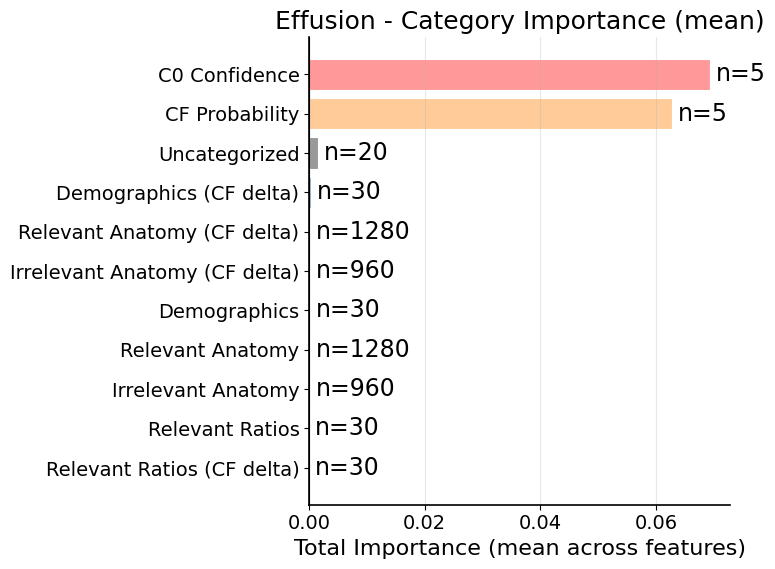

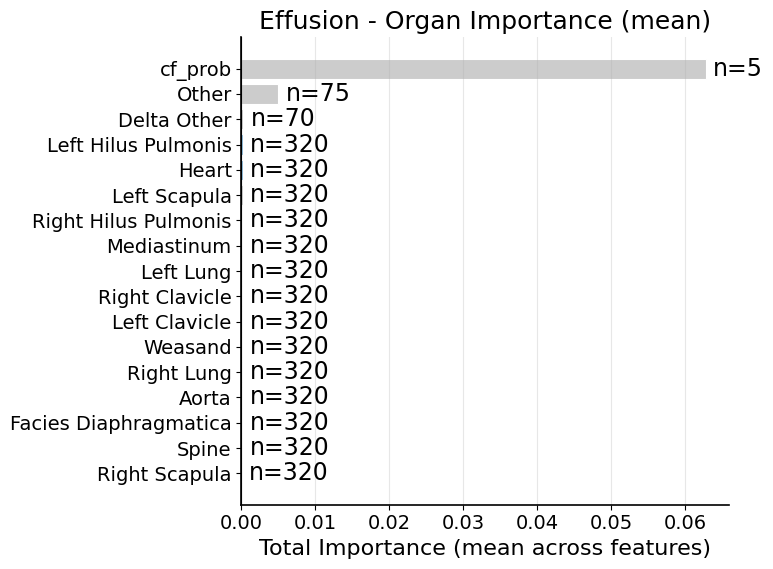

                            group      mean       sum  count
0                   C0 Confidence  0.069352  0.346758      5
1                  CF Probability  0.062756  0.313779      5
10                  Uncategorized  0.001491  0.029819     20
3         Demographics (CF delta)  0.000373  0.011200     30
7     Relevant Anatomy (CF delta)  0.000156  0.200095   1280
5   Irrelevant Anatomy (CF delta)  0.000122  0.117468    960
2                    Demographics  0.000101  0.003032     30
6                Relevant Anatomy  0.000093  0.118505   1280
4              Irrelevant Anatomy  0.000086  0.082580    960
8                 Relevant Ratios  0.000023  0.000693     30


In [120]:
metric = 'mean'
category_importance = aggregate_importances(all_importances, categorize_feature_v3, metric=metric)
organ_importance = aggregate_importances(all_importances, categorize_by_organ, metric=metric)

organ_colors = {
    organ: ('#88BBDD' if organ in RELEVANT_STRUCTURES else '#CCCCCC')
    for organ in organ_importance['group']
}

plot_group_importance(
    category_importance,
    title=f'{DISEASE.capitalize()} - Category Importance',
    color_map=category_colors,
    save_path=f'{DISEASE}_category_importance_{metric}.png',
    metric=metric
)
plot_group_importance(
    organ_importance,
    title=f'{DISEASE.capitalize()} - Organ Importance',
    color_map=organ_colors,
    save_path=f'{DISEASE}_organ_importance_{metric}.png',
    metric=metric
)

print(category_importance[['group', 'mean', 'sum', 'count']].sort_values('mean', ascending=False).head(10))

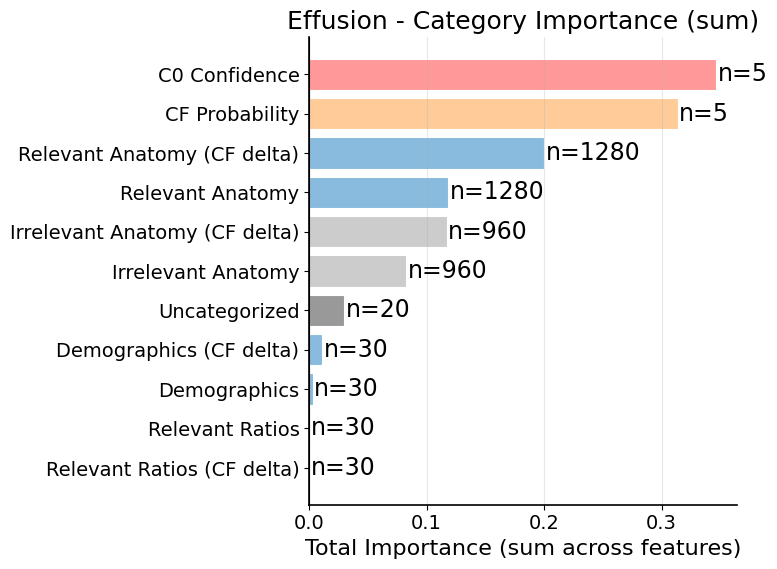

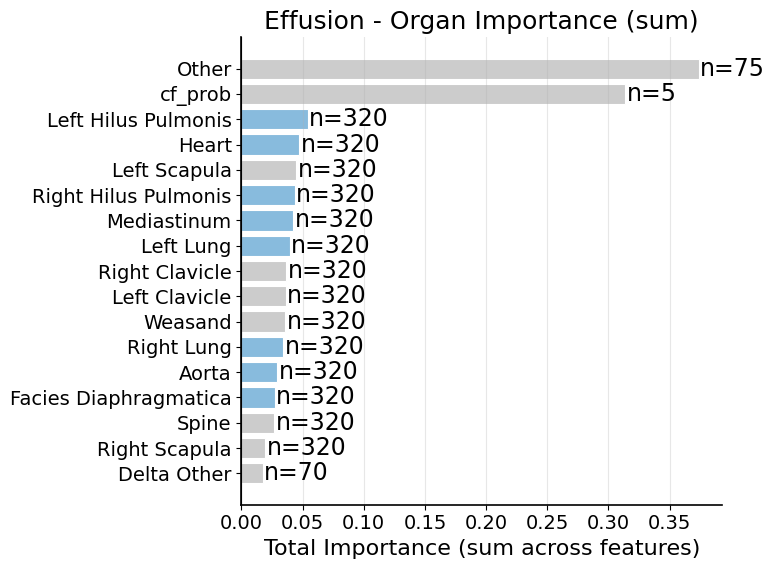

                            group      mean       sum  count
0                   C0 Confidence  0.069352  0.346758      5
1                  CF Probability  0.062756  0.313779      5
7     Relevant Anatomy (CF delta)  0.000156  0.200095   1280
6                Relevant Anatomy  0.000093  0.118505   1280
5   Irrelevant Anatomy (CF delta)  0.000122  0.117468    960
4              Irrelevant Anatomy  0.000086  0.082580    960
10                  Uncategorized  0.001491  0.029819     20
3         Demographics (CF delta)  0.000373  0.011200     30
2                    Demographics  0.000101  0.003032     30
8                 Relevant Ratios  0.000023  0.000693     30


In [121]:
metric = 'sum'
category_importance = aggregate_importances(all_importances, categorize_feature_v3, metric=metric)
organ_importance = aggregate_importances(all_importances, categorize_by_organ, metric=metric)

organ_colors = {
    organ: ('#88BBDD' if organ in RELEVANT_STRUCTURES else '#CCCCCC')
    for organ in organ_importance['group']
}

plot_group_importance(
    category_importance,
    title=f'{DISEASE.capitalize()} - Category Importance',
    color_map=category_colors,
    save_path=f'{DISEASE}_category_importance_{metric}.png',
    metric=metric
)
plot_group_importance(
    organ_importance,
    title=f'{DISEASE.capitalize()} - Organ Importance',
    color_map=organ_colors,
    save_path=f'{DISEASE}_organ_importance_{metric}.png',
    metric=metric
)

print(category_importance[['group', 'mean', 'sum', 'count']].sort_values('sum', ascending=False).head(10))